In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from os.path import exists

sys.path.append('../..')

In [3]:
import pylab as plt
import pandas as pd
import numpy as np
from loguru import logger
import seaborn as sns

from stable_baselines3 import PPO, DQN

In [4]:
from vimms.Common import POSITIVE, set_log_level_warning, load_obj, save_obj
from vimms.ChemicalSamplers import MZMLFormulaSampler, MZMLRTandIntensitySampler, MZMLChromatogramSampler
from vimms.Noise import UniformSpikeNoise
from vimms.Roi import RoiBuilderParams, SmartRoiParams

from vimms_gym.chemicals import generate_chemicals
from vimms_gym.evaluation import evaluate, run_method
from vimms_gym.common import METHOD_RANDOM, METHOD_TOPN, METHOD_PPO, METHOD_DQN

/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex
/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/psims/mzmlb/writer.py:15: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


# 1. Parameters

In [5]:
n_chemicals = (30000, 50000)
mz_range = (70, 1000)
rt_range = (0, 1440)
intensity_range = (1E4, 1E20)

In [6]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [7]:
isolation_window = 0.7
N = 10
rt_tol = 120
exclusion_t_0 = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [8]:
mzml_filename = '../fullscan_QCB.mzML'
samplers = None
samplers_pickle = 'samplers_fullscan_QCB.mzML.p'
if exists(samplers_pickle):
    logger.info('Loaded %s' % samplers_pickle)
    samplers = load_obj(samplers_pickle)
    mz_sampler = samplers['mz']
    ri_sampler = samplers['rt_intensity']
    cr_sampler = samplers['chromatogram']
else:
    logger.info('Creating samplers from %s' % mzml_filename)
    mz_sampler = MZMLFormulaSampler(mzml_filename, min_mz=min_mz, max_mz=max_mz)
    ri_sampler = MZMLRTandIntensitySampler(mzml_filename, min_rt=min_rt, max_rt=max_rt,
                                           min_log_intensity=min_log_intensity,
                                           max_log_intensity=max_log_intensity)
    roi_params = RoiBuilderParams(min_roi_length=3, at_least_one_point_above=1000)
    cr_sampler = MZMLChromatogramSampler(mzml_filename, roi_params=roi_params)
    samplers = {
        'mz': mz_sampler,
        'rt_intensity': ri_sampler,
        'chromatogram': cr_sampler
    }
    save_obj(samplers, samplers_pickle)

2022-05-26 23:04:19.622 | INFO     | __main__:<module>:5 - Loaded samplers_fullscan_QCB.mzML.p


In [9]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

In [10]:
max_peaks = 200
in_dir = 'results'

In [11]:
n_eval_episodes = 5
deterministic = True

# 2. Evaluation

#### Generate some chemical sets

In [12]:
set_log_level_warning()

1

In [13]:
eval_dir = 'evaluation'
methods = [
    METHOD_PPO,
    METHOD_TOPN,
    METHOD_RANDOM,
]

In [14]:
chemical_creator_params = params['chemical_creator']

chem_list = []
for i in range(n_eval_episodes):
    print(i)
    chems = generate_chemicals(chemical_creator_params)
    chem_list.append(chems)

0
1
2
3
4


#### Run different methods

In [15]:
for chems in chem_list:
    print(len(chems))

45821
36687
40797
41736
40986


In [16]:
max_peaks

200

In [17]:
out_dir = eval_dir
in_dir, out_dir

('results', 'evaluation')

#### Compare to Top-10

In [18]:
env_name = 'DDAEnv'
model_name = 'PPO'
intensity_threshold = 0.5

In [19]:
method_eval_results = {}
for method in methods:

    if method in (METHOD_PPO, METHOD_DQN):
        effective_rt_tol = rt_tol
    else:
        effective_rt_tol = exclusion_t_0        
    copy_params = dict(params)        
    copy_params['env']['rt_tol'] = effective_rt_tol
    
    banner = 'method = %s max_peaks = %d rt_tol = %d' % (method, max_peaks, effective_rt_tol)
    print(banner)
    print()

    if method == METHOD_PPO:
        fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
        model = PPO.load(fname)
    elif method == METHOD_DQN:
        fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
        model = DQN.load(fname)
    else:
        model = None

    episodic_results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, 
                                  N=N, min_ms1_intensity=min_ms1_intensity, model=model,
                                  print_eval=True, print_reward=False, intensity_threshold=intensity_threshold)
    eval_results = [er.eval_res for er in episodic_results]
    method_eval_results[method] = eval_results
    print()

method = PPO max_peaks = 200 rt_tol = 120

{'coverage_prop': '0.229', 'intensity_prop': '0.158', 'ms1/ms2 ratio': '0.160', 'efficiency': '1.927', 'TP': '2505', 'FP': '669', 'FN': '42647', 'precision': '0.789', 'recall': '0.055', 'f1': '0.104'}
{'coverage_prop': '0.239', 'intensity_prop': '0.164', 'ms1/ms2 ratio': '0.170', 'efficiency': '1.629', 'TP': '2589', 'FP': '685', 'FN': '33413', 'precision': '0.791', 'recall': '0.072', 'f1': '0.132'}
{'coverage_prop': '0.232', 'intensity_prop': '0.159', 'ms1/ms2 ratio': '0.165', 'efficiency': '1.750', 'TP': '2441', 'FP': '688', 'FN': '37668', 'precision': '0.780', 'recall': '0.061', 'f1': '0.113'}
{'coverage_prop': '0.229', 'intensity_prop': '0.157', 'ms1/ms2 ratio': '0.172', 'efficiency': '1.783', 'TP': '2473', 'FP': '708', 'FN': '38555', 'precision': '0.777', 'recall': '0.060', 'f1': '0.112'}
{'coverage_prop': '0.236', 'intensity_prop': '0.163', 'ms1/ms2 ratio': '0.166', 'efficiency': '1.789', 'TP': '2514', 'FP': '706', 'FN': '37766', 'precisi

#### Test classic controllers in ViMMS

In [20]:
from vimms.MassSpec import IndependentMassSpectrometer
from vimms.Controller import TopNController, TopN_SmartRoiController, WeightedDEWController
from vimms.Environment import Environment

Run Top-N Controller

In [21]:
method = 'TopN_Controller'
print('method = %s' % method)
print()

effective_rt_tol = rt_tol
eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    controller = TopNController(ionisation_mode, N, isolation_window, mz_tol, effective_rt_tol,
                                min_ms1_intensity)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i), save_eval=True)
    env.run()
    
    eval_res = evaluate(env, intensity_threshold)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = TopN_Controller

Episode 0 finished
{'coverage_prop': '0.226', 'intensity_prop': '0.155', 'ms1/ms2 ratio': '0.104', 'efficiency': '1.735', 'TP': '2496', 'FP': '727', 'FN': '42598', 'precision': '0.774', 'recall': '0.055', 'f1': '0.103'}
Episode 1 finished
{'coverage_prop': '0.244', 'intensity_prop': '0.167', 'ms1/ms2 ratio': '0.112', 'efficiency': '1.519', 'TP': '2722', 'FP': '724', 'FN': '33241', 'precision': '0.790', 'recall': '0.076', 'f1': '0.138'}
Episode 2 finished
{'coverage_prop': '0.234', 'intensity_prop': '0.161', 'ms1/ms2 ratio': '0.107', 'efficiency': '1.611', 'TP': '2549', 'FP': '733', 'FN': '37515', 'precision': '0.777', 'recall': '0.064', 'f1': '0.118'}
Episode 3 finished
{'coverage_prop': '0.235', 'intensity_prop': '0.161', 'ms1/ms2 ratio': '0.106', 'efficiency': '1.650', 'TP': '2629', 'FP': '733', 'FN': '38374', 'precision': '0.782', 'recall': '0.064', 'f1': '0.119'}
Episode 4 finished
{'coverage_prop': '0.241', 'intensity_prop': '0.166', 'ms1/ms2 ratio': '0.1

Run SmartROI Controller

In [22]:
method = 'SmartROI_Controller'
print('method = %s' % method)
print()

effective_rt_tol = exclusion_t_0
eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    
    roi_params = RoiBuilderParams(min_roi_intensity=500, min_roi_length=0)    
    smartroi_params = SmartRoiParams()
    controller = TopN_SmartRoiController(ionisation_mode, isolation_window, N, mz_tol, effective_rt_tol,
                                min_ms1_intensity, roi_params, smartroi_params)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i), save_eval=True)
    env.run()
    
    eval_res = evaluate(env, intensity_threshold)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = SmartROI_Controller

Episode 0 finished
{'coverage_prop': '0.218', 'intensity_prop': '0.149', 'ms1/ms2 ratio': '0.276', 'efficiency': '2.150', 'TP': '2104', 'FP': '773', 'FN': '42944', 'precision': '0.731', 'recall': '0.047', 'f1': '0.088'}
Episode 1 finished
{'coverage_prop': '0.225', 'intensity_prop': '0.153', 'ms1/ms2 ratio': '0.338', 'efficiency': '1.918', 'TP': '2086', 'FP': '774', 'FN': '33827', 'precision': '0.729', 'recall': '0.058', 'f1': '0.108'}
Episode 2 finished
{'coverage_prop': '0.217', 'intensity_prop': '0.148', 'ms1/ms2 ratio': '0.318', 'efficiency': '2.016', 'TP': '2057', 'FP': '701', 'FN': '38039', 'precision': '0.746', 'recall': '0.051', 'f1': '0.096'}
Episode 3 finished
{'coverage_prop': '0.220', 'intensity_prop': '0.149', 'ms1/ms2 ratio': '0.294', 'efficiency': '2.023', 'TP': '2082', 'FP': '827', 'FN': '38827', 'precision': '0.716', 'recall': '0.051', 'f1': '0.095'}
Episode 4 finished
{'coverage_prop': '0.223', 'intensity_prop': '0.153', 'ms1/ms2 ratio': 

Run WeightedDEW Controller

In [23]:
method = 'WeightedDEW_Controller'
print('method = %s' % method)
print()

eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    
    controller = WeightedDEWController(ionisation_mode, N, isolation_window, mz_tol, rt_tol,
                                min_ms1_intensity, exclusion_t_0=exclusion_t_0)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i), save_eval=True)
    env.run()
    
    eval_res = evaluate(env, intensity_threshold)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = WeightedDEW_Controller

Episode 0 finished
{'coverage_prop': '0.225', 'intensity_prop': '0.154', 'ms1/ms2 ratio': '0.102', 'efficiency': '1.724', 'TP': '2450', 'FP': '693', 'FN': '42678', 'precision': '0.780', 'recall': '0.054', 'f1': '0.102'}
Episode 1 finished
{'coverage_prop': '0.237', 'intensity_prop': '0.164', 'ms1/ms2 ratio': '0.106', 'efficiency': '1.465', 'TP': '2607', 'FP': '694', 'FN': '33386', 'precision': '0.790', 'recall': '0.072', 'f1': '0.133'}
Episode 2 finished
{'coverage_prop': '0.239', 'intensity_prop': '0.165', 'ms1/ms2 ratio': '0.103', 'efficiency': '1.634', 'TP': '2453', 'FP': '721', 'FN': '37623', 'precision': '0.773', 'recall': '0.061', 'f1': '0.113'}
Episode 3 finished
{'coverage_prop': '0.231', 'intensity_prop': '0.159', 'ms1/ms2 ratio': '0.103', 'efficiency': '1.616', 'TP': '2452', 'FP': '729', 'FN': '38555', 'precision': '0.771', 'recall': '0.060', 'f1': '0.111'}
Episode 4 finished
{'coverage_prop': '0.240', 'intensity_prop': '0.165', 'ms1/ms2 ratio

#### Plotting

Flatten data into dataframe

In [24]:
data = []
for method in method_eval_results:
    eval_results = method_eval_results[method]
    for eval_res in eval_results:
        row = (
            method, 
            float(eval_res['coverage_prop']), 
            float(eval_res['intensity_prop']), 
            float(eval_res['ms1/ms2 ratio']), 
            float(eval_res['efficiency']),
            float(eval_res['precision']),
            float(eval_res['recall']),
            float(eval_res['f1']),            
        )
        data.append(row)
        
df = pd.DataFrame(data, columns=['method', 'coverage_prop', 'intensity_prop', 'ms1/ms2_ratio', 'efficiency', 'precision', 'recall', 'f1'])
# df.set_index('method', inplace=True)
df.head()

,method,coverage_prop,intensity_prop,ms1/ms2_ratio,efficiency,precision,recall,f1
0,PPO,0.229,0.158,0.160,1.927,0.789,0.055,0.104
1,PPO,0.239,0.164,0.170,1.629,0.791,0.072,0.132
2,PPO,0.232,0.159,0.165,1.750,0.780,0.061,0.113
3,PPO,0.229,0.157,0.172,1.783,0.777,0.060,0.112
4,PPO,0.236,0.163,0.166,1.789,0.781,0.062,0.116


In [25]:
sns.set_context("poster")

Text(0.5, 1.0, 'Coverage Proportion')

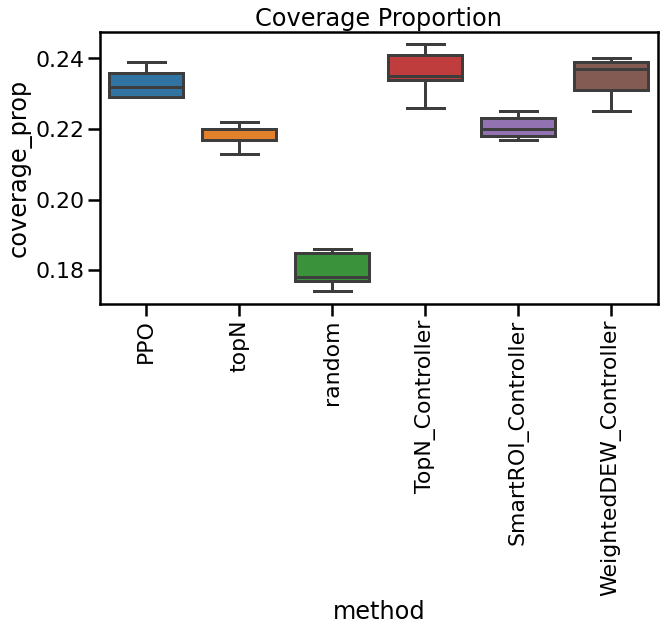

In [26]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='coverage_prop')
plt.xticks(rotation=90)
plt.title('Coverage Proportion')

Text(0.5, 1.0, 'Intensity Proportion')

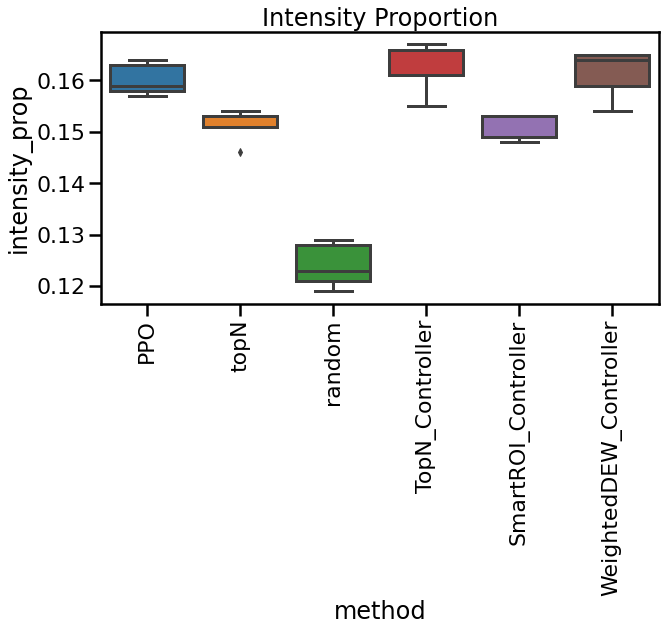

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='intensity_prop')
plt.xticks(rotation=90)
plt.title('Intensity Proportion')

Text(0.5, 1.0, 'MS1/MS2 Ratio')

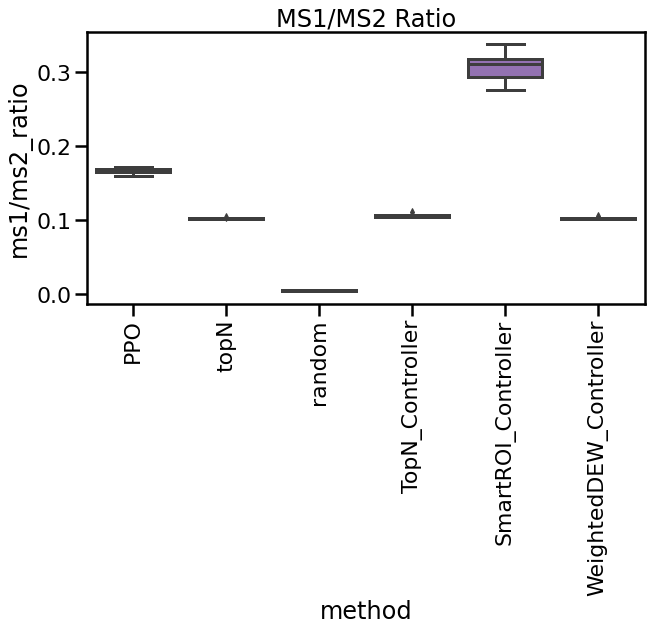

In [28]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='ms1/ms2_ratio')
plt.xticks(rotation=90)
plt.title('MS1/MS2 Ratio')

Text(0.5, 1.0, 'Efficiency')

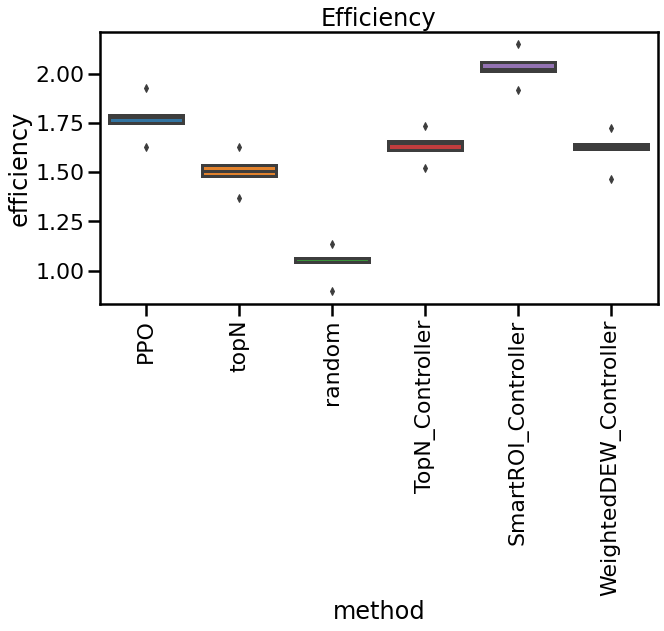

In [29]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='efficiency')
plt.xticks(rotation=90)
plt.title('Efficiency')

Text(0.5, 1.0, 'Precision')

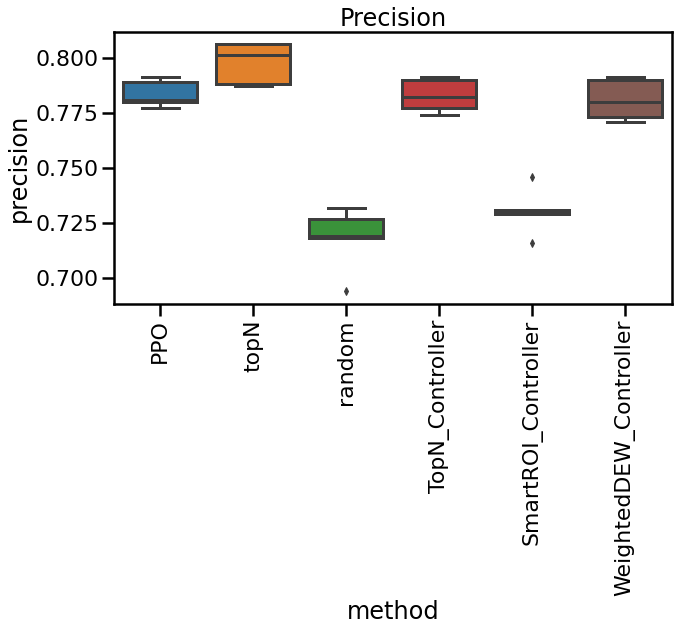

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='precision')
plt.xticks(rotation=90)
plt.title('Precision')

Text(0.5, 1.0, 'Recall')

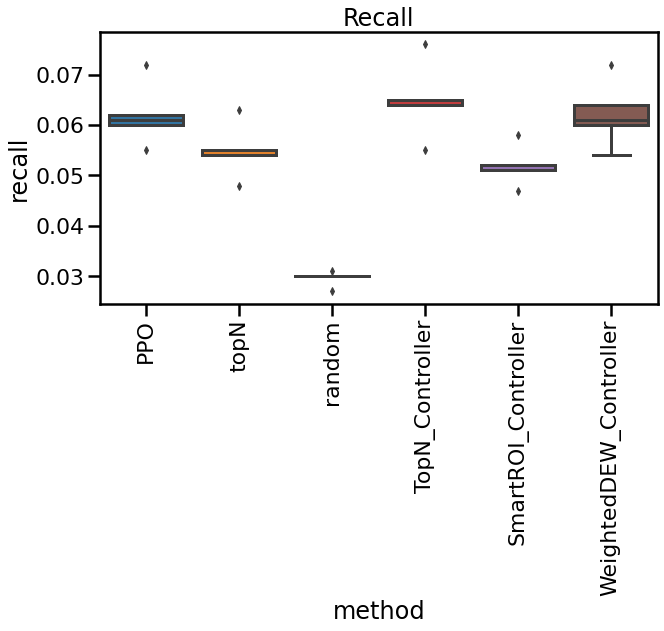

In [31]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='recall')
plt.xticks(rotation=90)
plt.title('Recall')

Text(0.5, 1.0, 'F1')

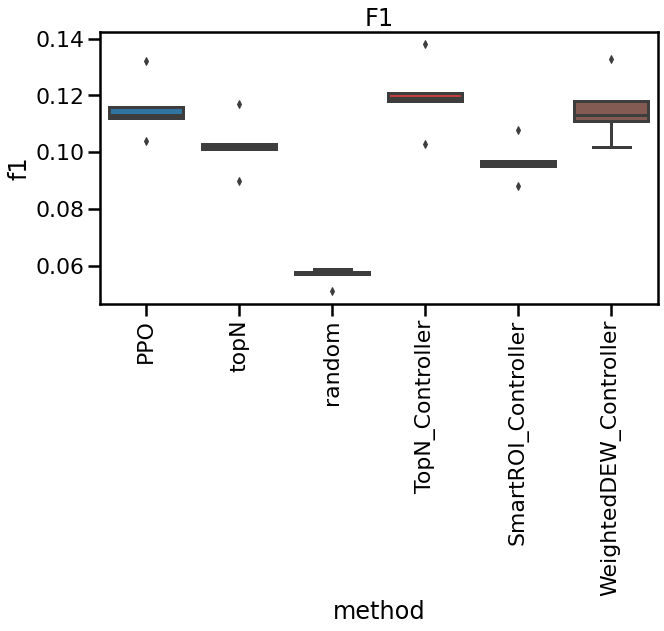

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='f1')
plt.xticks(rotation=90)
plt.title('F1')